In [1]:
from pathlib import Path
import sys
import os
import warnings

# warnings.filterwarnings("error")
# Add parent directory to Python path
project_root = Path("/home/nbyrnes/code/random-matrix/")  # <-- adjust this
sys.path.insert(0, str(project_root))
from scipy.sparse.linalg import eigsh
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse
import shapely
import sksparse
import tqdm
import quadpy
import warnings
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
    scattering_geometry,
)
from random_matrix.input_statistics import (
    density_function,
    density_integrals,
    input_statistics_manager,
)
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.amplitude_matrix import isotropic_sphere
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix import sampler

In [2]:
import numpy as np
import scipy as sp
import scipy.linalg
import scipy.special
import scipy.optimize
import scipy.sparse
import sksparse.cholmod
from pathos.multiprocessing import ProcessingPool as Pool


def sinc(x):
    if np.isclose(x, 0):
        return 1.0
    else:
        return np.sin(x) / x


def get_angle_plane(v1, v2, n):
    """
    Calculate rotation angle used in A matrix calculation
    See Appendix D for more inforamtion
    """

    # Special cases
    cosine = np.dot(v1, v2)

    if cosine >= 1 or np.isclose(cosine, 1):
        return 0
    elif cosine <= -1 or np.isclose(cosine, -1):
        return np.pi

    theta = np.arccos(cosine)

    # check if n is in the same direction as v1xv2
    k = np.cross(v1, v2)
    k = k / np.linalg.norm(k)

    alignment = np.dot(k, n)
    if np.isclose(alignment, 1):
        alpha = theta
    else:
        alpha = -theta

    return alpha


def get_T(k1, k2, params, N_lim=5):
    """
    Calculate far-field single scattering matrix (A) using Mie theory
    k1 = incident wavevector
    k2 = outgoing wavevector
    params must contain:
        'x': size parameter
        'm': relative refractive index
        'type': scattering type (rayleigh, mie or chiral)
            if 'type' is 'chiral' then params must also contain 'mL' and 'mR',
            the relative refractive indices for left and right handed
            circularly polarized light

    N_lim is the number of terms used in calculating the scattering
    coefficients. Increase for greater accuracy.
    """

    k1 = k1 / np.linalg.norm(k1)
    k2 = k2 / np.linalg.norm(k2)

    for i, component in enumerate(k1):
        if np.isclose(component, 0):
            k1[i] = 0
    for i, component in enumerate(k2):
        if np.isclose(component, 0):
            k2[i] = 0

    x = params["x"]
    m = params["m"]
    M_type = params["type"]

    if M_type == "chiral":
        mL = params["mL"]
        mR = params["mR"]

    theta_i = np.arccos(k1[2])
    phi_i = np.arctan2(k1[1], k1[0])
    theta_s = np.arccos(k2[2])
    phi_s = np.arctan2(k2[1], k2[0])
    cos_theta_scattering = np.dot(k1, k2)

    if np.allclose(k1, np.array([0, 0, -1])):
        e_theta_i = np.array([1, 0, 0])
        e_phi_i = np.array([0, -1, 0])
    else:
        e_theta_i = np.array(
            [
                np.cos(theta_i) * np.cos(phi_i),
                np.cos(theta_i) * np.sin(phi_i),
                -np.sin(theta_i),
            ]
        )
        e_phi_i = np.array([-np.sin(phi_i), np.cos(phi_i), 0])

    if np.allclose(k2, np.array([0, 0, -1])):
        e_theta_s = np.array([1, 0, 0])
        # e_phi_s = np.array([0,-1,0])
    else:
        e_theta_s = np.array(
            [
                np.cos(theta_s) * np.cos(phi_s),
                np.cos(theta_s) * np.sin(phi_s),
                -np.sin(theta_s),
            ]
        )
        # e_phi_s = np.array([-np.sin(phi_s), np.cos(phi_s), 0])

    if np.allclose(k1, k2):
        e_par_i = e_theta_i
        e_par_s = e_theta_s
        e_per = e_phi_i
        alpha1 = 0
        alpha2 = 0
    elif np.allclose(k1, -k2):
        e_par_i = e_theta_i
        e_par_s = -e_theta_s
        e_per = e_phi_i
        alpha1 = 0
        alpha2 = np.pi

    else:
        e_per = np.cross(k1, k2)
        e_per = e_per / np.linalg.norm(e_per)

        e_par_i = np.cross(e_per, k1)
        e_par_i = e_par_i / np.linalg.norm(e_par_i)

        e_par_s = np.cross(e_per, k2)
        e_par_s = e_par_s / np.linalg.norm(e_par_s)

        alpha1 = get_angle_plane(e_theta_i, e_par_i, k1)
        alpha2 = get_angle_plane(e_par_s, e_theta_s, k2)

    T1 = np.array(
        [[np.cos(alpha1), np.sin(alpha1)], [-np.sin(alpha1), np.cos(alpha1)]]
    )
    T2 = np.array([[1, 0], [0, -1]])
    T4 = np.array([[1, 0], [0, -1]])
    T5 = np.array(
        [[np.cos(alpha2), np.sin(alpha2)], [-np.sin(alpha2), np.cos(alpha2)]]
    )

    if M_type == "rayleigh":
        a1 = -1j * x**3 * (m**2 - 1) / (m**2 + 2)
        S1 = a1 * 1
        S2 = a1 * cos_theta_scattering
        T3 = np.array([[S2, 0], [0, S1]])

    elif M_type == "mie":
        mu = np.dot(k1, k2)

        psi_x = sp.special.riccati_jn(N_lim, x)
        psi_mx = sp.special.riccati_jn(N_lim, m * x)
        phi_x = sp.special.riccati_yn(N_lim, x)
        xi_x = [psi + 1j * phi for psi, phi in zip(psi_x, phi_x)]

        S1 = 0
        S2 = 0
        for n in range(1, N_lim):
            a = (
                m * psi_mx[0][n] * psi_x[1][n] - psi_x[0][n] * psi_mx[1][n]
            ) / (m * psi_mx[0][n] * xi_x[1][n] - xi_x[0][n] * psi_mx[1][n])
            b = (
                psi_mx[0][n] * psi_x[1][n] - m * psi_x[0][n] * psi_mx[1][n]
            ) / (psi_mx[0][n] * xi_x[1][n] - m * xi_x[0][n] * psi_mx[1][n])
            S1 = S1 + (2 * n + 1) / (n * (n + 1)) * (
                a * pi(n, mu) + b * tau(n, mu)
            )
            S2 = S2 + (2 * n + 1) / (n * (n + 1)) * (
                a * tau(n, mu) + b * pi(n, mu)
            )

        T3 = np.array([[S2, 0], [0, S1]])

    elif M_type == "chiral":
        mu = np.dot(k1, k2)

        psi_x = sp.special.riccati_jn(N_lim, x)
        psi_mLx = sp.special.riccati_jn(N_lim, mL * x)
        psi_mRx = sp.special.riccati_jn(N_lim, mR * x)
        phi_x = sp.special.riccati_yn(N_lim, x)
        xi_x = [psi + 1j * phi for psi, phi in zip(psi_x, phi_x)]

        S1 = 0
        S2 = 0
        S3 = 0
        for n in range(1, N_lim):
            new_pi = pi(n, mu)
            new_tau = tau(n, mu)

            WL = m * psi_mLx[0][n] * xi_x[1][n] - xi_x[0][n] * psi_mLx[1][n]
            WR = m * psi_mRx[0][n] * xi_x[1][n] - xi_x[0][n] * psi_mRx[1][n]
            VL = psi_mLx[0][n] * xi_x[1][n] - m * xi_x[0][n] * psi_mLx[1][n]
            VR = psi_mRx[0][n] * xi_x[1][n] - m * xi_x[0][n] * psi_mRx[1][n]
            AL = m * psi_mLx[0][n] * psi_x[1][n] - psi_x[0][n] * psi_mLx[1][n]
            AR = m * psi_mRx[0][n] * psi_x[1][n] - psi_x[0][n] * psi_mRx[1][n]
            BL = psi_mLx[0][n] * psi_x[1][n] - m * psi_x[0][n] * psi_mLx[1][n]
            BR = psi_mRx[0][n] * psi_x[1][n] - m * psi_x[0][n] * psi_mRx[1][n]

            a = (VR * AL + VL * AR) / (WL * VR + VL * WR)
            b = (WL * BR + WR * BL) / (WL * VR + VL * WR)
            c = 1j * (WR * AL - WL * AR) / (WL * VR + VL * WR)

            S1 = S1 + (2 * n + 1) / (n * (n + 1)) * (a * new_pi + b * new_tau)
            S2 = S2 + (2 * n + 1) / (n * (n + 1)) * (a * new_tau + b * new_pi)
            S3 = S3 + (2 * n + 1) / (n * (n + 1)) * c * (new_pi + new_tau)
        T3 = np.array([[S2, S3], [-S3, S1]])
    T = -T5 @ T4 @ T3 @ T2 @ T1

    return T


def R_sym(M):
    """
    Returns the 'reciprocal operator' applied to a matrix as defined in
    https://journals.aps.org/prresearch/abstract/10.1103/PhysRevResearch.3.013129
    """
    x, y = np.shape(M)
    b = np.ones((y, x), dtype=np.complex128)
    b[1::2, ::2] = -1.0
    b[::2, 1::2] = -1.0
    out = np.multiply(M.T, b)
    return out


def mie_cross_section(x, m, k, N_lim=20):
    psi_x = sp.special.riccati_jn(N_lim, x)
    psi_mx = sp.special.riccati_jn(N_lim, m * x)
    phi_x = sp.special.riccati_yn(N_lim, x)
    xi_x = [psi + 1j * phi for psi, phi in zip(psi_x, phi_x)]

    C_sca = 0
    C_ext = 0
    for n in range(1, N_lim):
        a = (m * psi_mx[0][n] * psi_x[1][n] - psi_x[0][n] * psi_mx[1][n]) / (
            m * psi_mx[0][n] * xi_x[1][n] - xi_x[0][n] * psi_mx[1][n]
        )
        b = (psi_mx[0][n] * psi_x[1][n] - m * psi_x[0][n] * psi_mx[1][n]) / (
            psi_mx[0][n] * xi_x[1][n] - m * xi_x[0][n] * psi_mx[1][n]
        )
        C_sca = C_sca + (2 * n + 1) * (
            np.absolute(a) ** 2 + np.absolute(b) ** 2
        )
        C_ext = C_ext + (2 * n + 1) * np.real(a + b)

    C_sca = 2 * np.pi * C_sca / k**2
    C_ext = 2 * np.pi * C_ext / k**2
    return C_sca, C_ext


def M2S(M):
    """
    Converts a transfer matrix into a scattering matrix
    """
    N, N = np.shape(M)
    N = int(N / 4)
    alpha = M[0 : 2 * N, 0 : 2 * N]
    gamma = M[2 * N : 4 * N, 0 : 2 * N]
    delta = M[2 * N : 4 * N, 2 * N : 4 * N]
    beta = M[0 : 2 * N, 2 * N : 4 * N]

    deltainv = sp.linalg.inv(delta)

    r = -deltainv @ gamma
    t = alpha - beta @ deltainv @ gamma
    t2 = deltainv
    r2 = beta @ deltainv

    S = np.block([[r, t2], [t, r2]])
    return S


# Returns the scattering matrix for a system composed of S1 then S2
def S_cascade(S1, S2, sigmap):
    """
    Calculates the scattering matrix of a system composed of two contiguous
    scattering media
    with scattering matrices S1 and S2

    See appendix B for more information
    """
    N, N = np.shape(S1)
    size = int(N / 2)

    r_1 = S1[0:size, 0:size]
    t_1 = S1[size:N, 0:size]
    t2_1 = S1[0:size, size:N]
    r2_1 = S1[size:N, size:N]

    r_2 = S2[0:size, 0:size]
    t_2 = S2[size:N, 0:size]
    t2_2 = S2[0:size, size:N]
    r2_2 = S2[size:N, size:N]

    Q = sp.linalg.inv(np.identity(size) - r2_1 @ r_2)

    r = r_1 + t2_1 @ r_2 @ Q @ t_1
    r2 = r2_2 + t_2 @ Q @ r2_1 @ t2_2
    t = t_2 @ Q @ t_1
    t2 = sigmap @ R_sym(t) @ sigmap

    S = np.block([[r, t2], [t, r2]])
    return S


def S_sample_svd(statistics, sigma_p):
    """
    Randomly generates a scattering matrix.
    Statistics is the output of the get_statistics function
    """
    mean_t = statistics["mean t"]
    mean_r = statistics["mean r"]
    mean_r2 = statistics["mean r2"]
    chol_t = statistics["chol t"]
    chol_r = statistics["chol r"]
    chol_r2 = statistics["chol r2"]
    n_modes = len(mean_t)

    t = np.zeros((2 * n_modes, 2 * n_modes), dtype=np.complex128)
    r = np.zeros((2 * n_modes, 2 * n_modes), dtype=np.complex128)
    r2 = np.zeros((2 * n_modes, 2 * n_modes), dtype=np.complex128)

    size = np.shape(chol_t)[0]
    random_numbers = np.random.randn(size)
    modified_t = chol_t @ random_numbers
    reals_t = modified_t[0 : int(size / 2)]
    imags_t = modified_t[int(size / 2) : int(size)]

    size = np.shape(chol_r)[0]
    random_numbers = np.random.randn(size)
    modified_r = chol_r @ random_numbers
    reals_r = modified_r[0 : int(size / 2)]
    imags_r = modified_r[int(size / 2) : int(size)]

    size = np.shape(chol_r2)[0]
    random_numbers = np.random.randn(size)
    modified_r2 = chol_r2 @ random_numbers
    reals_r2 = modified_r2[0 : int(size / 2)]
    imags_r2 = modified_r2[int(size / 2) : int(size)]

    # helper function
    def h(i, n_modes):
        row = np.floor(i / n_modes)
        col = i % n_modes
        return int(row), int(col)

    for i in range(n_modes**2):
        row, col = h(i, n_modes)
        if row == col:
            t[2 * row, 2 * col] = mean_t[row][0, 0]
            t[2 * row, 2 * col + 1] = mean_t[row][0, 1]
            t[2 * row + 1, 2 * col] = mean_t[row][1, 0]
            t[2 * row + 1, 2 * col + 1] = mean_t[row][1, 1]

            r[2 * row, 2 * col] = (
                reals_r[4 * i] + 1j * imags_r[4 * i] + mean_r[row][0, 0]
            )
            r[2 * row, 2 * col + 1] = (
                reals_r[4 * i + 1]
                + 1j * imags_r[4 * i + 1]
                + mean_r[row][0, 1]
            )
            r[2 * row + 1, 2 * col] = (
                reals_r[4 * i + 2]
                + 1j * imags_r[4 * i + 2]
                + mean_r[row][1, 0]
            )
            r[2 * row + 1, 2 * col + 1] = (
                reals_r[4 * i + 3]
                + 1j * imags_r[4 * i + 3]
                + mean_r[row][1, 1]
            )

            r2[2 * row, 2 * col] = (
                reals_r2[4 * i] + 1j * imags_r2[4 * i] + mean_r2[row][0, 0]
            )
            r2[2 * row, 2 * col + 1] = (
                reals_r2[4 * i + 1]
                + 1j * imags_r2[4 * i + 1]
                + mean_r2[row][0, 1]
            )
            r2[2 * row + 1, 2 * col] = (
                reals_r2[4 * i + 2]
                + 1j * imags_r2[4 * i + 2]
                + mean_r2[row][1, 0]
            )
            r2[2 * row + 1, 2 * col + 1] = (
                reals_r2[4 * i + 3]
                + 1j * imags_r2[4 * i + 3]
                + mean_r2[row][1, 1]
            )

        else:
            t[2 * row, 2 * col] = reals_t[4 * i] + 1j * imags_t[4 * i]
            t[2 * row, 2 * col + 1] = (
                reals_t[4 * i + 1] + 1j * imags_t[4 * i + 1]
            )
            t[2 * row + 1, 2 * col] = (
                reals_t[4 * i + 2] + 1j * imags_t[4 * i + 2]
            )
            t[2 * row + 1, 2 * col + 1] = (
                reals_t[4 * i + 3] + 1j * imags_t[4 * i + 3]
            )

            r[2 * row, 2 * col] = reals_r[4 * i] + 1j * imags_r[4 * i]
            r[2 * row, 2 * col + 1] = (
                reals_r[4 * i + 1] + 1j * imags_r[4 * i + 1]
            )
            r[2 * row + 1, 2 * col] = (
                reals_r[4 * i + 2] + 1j * imags_r[4 * i + 2]
            )
            r[2 * row + 1, 2 * col + 1] = (
                reals_r[4 * i + 3] + 1j * imags_r[4 * i + 3]
            )

            r2[2 * row, 2 * col] = reals_r2[4 * i] + 1j * imags_r2[4 * i]
            r2[2 * row, 2 * col + 1] = (
                reals_r2[4 * i + 1] + 1j * imags_r2[4 * i + 1]
            )
            r2[2 * row + 1, 2 * col] = (
                reals_r2[4 * i + 2] + 1j * imags_r2[4 * i + 2]
            )
            r2[2 * row + 1, 2 * col + 1] = (
                reals_r2[4 * i + 3] + 1j * imags_r2[4 * i + 3]
            )

    # Symmetrize (r and r2 should already be symmetrized to that these steps
    # have no effect...
    #            but just to clean out any numerical inaccuracies)
    r = (r + sigma_p @ R_sym(r) @ sigma_p) / 2
    r2 = (r2 + sigma_p @ R_sym(r2) @ sigma_p) / 2
    t2 = sigma_p @ R_sym(t) @ sigma_p
    I = np.identity(2 * n_modes)

    t_svd = t + I
    t2_svd = t2 + I
    r_svd = r
    r2_svd = r2

    S_svd = np.block([[r_svd, t2_svd], [t_svd, r2_svd]])
    u, s, vh = sp.linalg.svd(S_svd)
    S = u @ vh

    return S


def S2M(S):
    """
    Converts a scattering matrix into a transfer matrix
    """
    N, N = np.shape(S)
    N = int(N / 4)
    r = S[0 : 2 * N, 0 : 2 * N]
    t = S[2 * N : 4 * N, 0 : 2 * N]
    r2 = S[2 * N : 4 * N, 2 * N : 4 * N]
    t2 = S[0 : 2 * N, 2 * N : 4 * N]

    t2inv = sp.linalg.inv(t2)

    alpha = t - r2 @ t2inv @ r
    beta = r2 @ t2inv
    gamma = -t2inv @ r
    delta = t2inv

    M = np.block([[alpha, beta], [gamma, delta]])
    return M


def mode_sample_cartesian(dx, dy):
    """
    Produces a cartesian grid of wavevector modes for given lattice spacings
    dx and dy
    """
    mode_list = []
    Nx = int(np.ceil(1 / dx))
    Ny = int(np.ceil(1 / dy))
    x = np.linspace(-Nx * dx, Nx * dx, 2 * Nx + 1)
    y = np.linspace(Ny * dy, -Ny * dy, 2 * Ny + 1)
    xv, yv = np.meshgrid(x, y)
    ny, nx = np.shape(xv)

    # Loop through mode centres
    for j in range(ny):
        for i in range(nx):
            x = xv[j, i]
            y = yv[j, i]

            if x**2 + y**2 < 1:
                mode_list.append(np.array([x, y]))

    n_modes = len(mode_list)
    weight = np.pi / n_modes

    return mode_list, weight


def get_mode_keys(mode_list):
    """
    The mode keys help keep track of the incident and outgoing wavevectors of
    different matrix blocks
    For example, t_key[j,i] contains and outgoing and incident wavevectors of
    the (j,i) 2x2 block of
    the transmission matrix
    """
    N_modes = len(mode_list)
    t_key = np.zeros((N_modes, N_modes), dtype="object")
    t2_key = np.zeros((N_modes, N_modes), dtype="object")
    r_key = np.zeros((N_modes, N_modes), dtype="object")
    r2_key = np.zeros((N_modes, N_modes), dtype="object")

    for i in range(N_modes):
        for j in range(N_modes):
            in_mode_left = mode_list[j].copy()
            in_mode_right = mode_list[j].copy()
            k_z_in = np.sqrt(1 - in_mode_left[0] ** 2 - in_mode_left[1] ** 2)
            in_mode_left = np.append(in_mode_left, [k_z_in])
            in_mode_right = np.append(in_mode_right, [-k_z_in])

            out_mode_left = mode_list[i].copy()
            out_mode_right = mode_list[i].copy()
            k_z_out = np.sqrt(
                1 - out_mode_left[0] ** 2 - out_mode_left[1] ** 2
            )
            out_mode_left = np.append(out_mode_left, [-k_z_out])
            out_mode_right = np.append(out_mode_right, [k_z_out])

            t_key[i][j] = [out_mode_right, in_mode_left]
            t2_key[i][j] = [out_mode_left, in_mode_right]
            r_key[i][j] = [out_mode_left, in_mode_left]
            r2_key[i][j] = [out_mode_right, in_mode_right]

    return {"r": r_key, "t": t_key, "r2": r2_key, "t2": t2_key}


## Parallelised construction of the covariance matrix
def get_statistics(params):
    """
    Generates lists of the mean matrices and cholesky decompositions of the
    correlation matrices associated with elements of the scattering matrix.

    The output of this function is to be used in S_sample_svd

    Note: the slowest part of this function uses multiprocessing for improved
    performance
    """
    N_cores = params["n cores"]

    k = params["k"]
    N = len(params["keys"]["t"])

    At_array = np.ndarray(shape=(N, N), dtype="object")
    Ar_array = np.ndarray(shape=(N, N), dtype="object")
    Ar2_array = np.ndarray(shape=(N, N), dtype="object")

    n = params["n"]
    tolerance = params["tol"]
    weight = params["weight"]

    tkey = params["keys"]["t"]
    rkey = params["keys"]["r"]
    r2key = params["keys"]["r2"]
    mode_list = params["modes"]

    print("Calculating A matrices...")
    # Calculate A matrices from Mie theory
    for i in range(N):
        for j in range(N):
            # Transmission
            kin = tkey[j, i][1]
            kout = tkey[j, i][0]

            A = get_T(kin, kout, params)
            At_array[j, i] = A

            # Reflection
            kin = rkey[j, i][1]
            kout = rkey[j, i][0]
            A = get_T(kin, kout, params)
            Ar_array[j, i] = A

            # Reflection 2
            kin = r2key[j, i][1]
            kout = r2key[j, i][0]
            A = get_T(kin, kout, params)
            Ar2_array[j, i] = A

    # Find experimental cross section
    css_x = []
    for i in range(N):
        newcs_x = 0
        for j in range(N):
            # sigma calculation
            size = mode_list[j][1]
            cos_theta = np.sqrt(1 - np.linalg.norm(mode_list[j][0]) ** 2)
            newcs_x = newcs_x + np.linalg.norm(
                At_array[j, i][:, 0]
            ) ** 2 * size / (k**2 * cos_theta)
            newcs_x = newcs_x + np.linalg.norm(
                Ar_array[j, i][:, 0]
            ) ** 2 * size / (k**2 * cos_theta)

        css_x.append(newcs_x)

    # Work out thickness that ensures the strength of the mean field in any
    # direction
    # is less than the tolerance (default value of tolerance is 0.1)

    Ls = []
    for i in range(N):
        cos_theta_i = np.sqrt(1 - np.linalg.norm(mode_list[i][0]) ** 2)
        Lnew = (
            tolerance
            * k**2
            * cos_theta_i
            / (np.max(sp.linalg.svdvals(At_array[i, i])) * 2 * np.pi * n)
        )
        Ls.append(Lnew)
    L = np.min(Ls)

    #########
    # Means #
    #########
    mean_t = []
    mean_r = []
    mean_r2 = []

    for i in range(N):
        kin_z = tkey[i, i][1][2]

        new_mean_t = 2 * np.pi * n * L / (k * k * kin_z) * At_array[i, i]
        new_mean_r = (
            2
            * np.pi
            * n
            * L
            / (k * k * kin_z)
            * Ar_array[i, i]
            * sinc(kin_z * k * L)
        )
        new_mean_r2 = (
            2
            * np.pi
            * n
            * L
            / (k * k * kin_z)
            * Ar2_array[i, i]
            * sinc(kin_z * k * L)
        )

        mean_t.append(new_mean_t)
        mean_r.append(new_mean_r)
        mean_r2.append(new_mean_r2)

    ####################
    # Helper functions #
    ####################

    # h1 takes the (j,i) coordinates of an element in t or r and converts it
    # to the number from
    # 0 to (2N)^2 that corresponds to it in the covariacne matrix
    def h1(j, i, Nmodes):
        return 4 * i + 4 * Nmodes * j

    # h2 takes a pair of elements in t (in t coordinates) and returns the
    # coordinates of the correlation between those elements
    # in the sparse matrix
    def h2(j, i, q, p, Nmodes):
        x = h1(j, i, Nmodes)
        y = h1(q, p, Nmodes)
        return (x, y)

    print("Setting up level sets...")

    ################################################
    # Algorithm for building covariance matrices

    # 1) Build differences matrix
    difference_matrix = np.zeros((N, N, 2), dtype=float)
    for j in range(N):
        for i in np.arange(j + 1, N):
            difference_matrix[j, i, :] = np.array(mode_list[i][0]) - np.array(
                mode_list[j][0]
            )
            difference_matrix[i, j, :] = -difference_matrix[j, i, :]

    # 2) Find level sets of differences matrix
    diagonal_level_set = [(i, i) for i in range(N)]
    level_sets = []
    conjugate_level_sets = []
    difference_list = []

    for j in range(N):
        for i in np.arange(j + 1, N):
            # new_set flag dictates whether or not a new level set needs to
            # be constructed
            new_set = True
            new_difference = difference_matrix[j, i, :]
            indices = (j, i)
            reverse_indices = (i, j)

            # Check if new_difference belongs to any of the level sets
            for index, difference in enumerate(difference_list):
                if np.allclose(difference, new_difference):
                    # new_difference belongs to the level set with index
                    # no need to make a new level set
                    level_sets[index].append(indices)
                    conjugate_level_sets[index].append(reverse_indices)
                    new_set = False
                    break
                if np.allclose(difference, -new_difference):
                    # the reverse of new_difference belongs to the level set
                    # with index
                    # no need to make a new level set
                    level_sets[index].append(reverse_indices)
                    conjugate_level_sets[index].append(indices)
                    new_set = False
                    break

            if new_set:
                difference_list.append(new_difference)
                new_level_set = [indices]
                new_conjugate_level_set = [reverse_indices]
                level_sets.append(new_level_set)
                conjugate_level_sets.append(new_conjugate_level_set)

    # 3) Loop over level sets and build up data array to be inserted into
    # sparse matrix
    data_array_t = np.zeros((0, 3), dtype="object")
    data_array_t_diagonals = np.zeros((0, 3), dtype="object")

    data_array_r = np.zeros((0, 3), dtype="object")
    data_array_r_diagonals = np.zeros((0, 3), dtype="object")

    data_array_r2 = np.zeros((0, 3), dtype="object")
    data_array_r2_diagonals = np.zeros((0, 3), dtype="object")

    pseudo_data_array_t = np.zeros((0, 3), dtype="object")
    pseudo_data_array_t_diagonals = np.zeros((0, 3), dtype="object")

    pseudo_data_array_r = np.zeros((0, 3), dtype="object")
    pseudo_data_array_r_diagonals = np.zeros((0, 3), dtype="object")

    pseudo_data_array_r2 = np.zeros((0, 3), dtype="object")
    pseudo_data_array_r2_diagonals = np.zeros((0, 3), dtype="object")

    print("Diagonal sets...")
    # Deal with diagonal_level_set
    for first_index in range(N):
        first_indices = diagonal_level_set[first_index]
        i = first_indices[1]
        j = first_indices[0]
        for second_index in np.arange(first_index, N):
            second_indices = diagonal_level_set[second_index]
            p = second_indices[1]
            q = second_indices[0]
            row, col = h2(j, i, q, p, N)

            in_first_t = np.array(tkey[j, i][1])
            out_first_t = np.array(tkey[j, i][0])
            in_second_t = np.array(tkey[q, p][1])
            out_second_t = np.array(tkey[q, p][0])

            kzi = in_first_t[2]
            kzj = out_first_t[2]
            kzp = in_second_t[2]
            kzq = out_second_t[2]

            ################
            # Transmission

            A_vec_ji = np.array(
                [
                    At_array[j, i][0, 0],
                    At_array[j, i][0, 1],
                    At_array[j, i][1, 0],
                    At_array[j, i][1, 1],
                ]
            )
            A_vec_qp = np.array(
                [
                    At_array[q, p][0, 0],
                    At_array[q, p][0, 1],
                    At_array[q, p][1, 0],
                    At_array[q, p][1, 1],
                ]
            )

            # Regular
            C = np.outer(A_vec_ji, np.conj(A_vec_qp))
            H = (
                C
                * n
                * L
                / k**2
                * weight
                * 1
                / np.sqrt(kzi * kzj * kzp * kzq)
                * sinc(k * L / 2 * ((kzi - kzj) - (kzp - kzq)))
            )

            new_data_entries_t = np.zeros((16, 3), dtype="object")
            new_data_entries_t[:, 0] = np.array(
                [row + 0] * 4 + [row + 1] * 4 + [row + 2] * 4 + [row + 3] * 4
            )
            new_data_entries_t[:, 1] = np.array(
                [col + 0, col + 1, col + 2, col + 3] * 4
            )
            new_data_entries_t[:, 2] = H.reshape(1, 16)

            if i == p and j == q:
                data_array_t_diagonals = np.vstack(
                    [data_array_t_diagonals, new_data_entries_t]
                )
            else:
                data_array_t = np.vstack([data_array_t, new_data_entries_t])

            # Pseudo
            C = np.outer(A_vec_ji, A_vec_qp)
            H = (
                C
                * n
                * L
                / k**2
                * weight
                * 1
                / np.sqrt(kzi * kzj * kzp * kzq)
                * sinc(k * L / 2 * ((kzi - kzj) + (kzp - kzq)))
            )

            new_data_entries_t = np.zeros((16, 3), dtype="object")
            new_data_entries_t[:, 0] = np.array(
                [row + 0] * 4 + [row + 1] * 4 + [row + 2] * 4 + [row + 3] * 4
            )
            new_data_entries_t[:, 1] = np.array(
                [col + 0, col + 1, col + 2, col + 3] * 4
            )
            new_data_entries_t[:, 2] = H.reshape(1, 16)

            if i == p and j == q:
                pseudo_data_array_t_diagonals = np.vstack(
                    [pseudo_data_array_t_diagonals, new_data_entries_t]
                )
            else:
                pseudo_data_array_t = np.vstack(
                    [pseudo_data_array_t, new_data_entries_t]
                )

            ###############
            # Reflection

            A_vec_ji = np.array(
                [
                    Ar_array[j, i][0, 0],
                    Ar_array[j, i][0, 1],
                    Ar_array[j, i][1, 0],
                    Ar_array[j, i][1, 1],
                ]
            )
            A_vec_qp = np.array(
                [
                    Ar_array[q, p][0, 0],
                    Ar_array[q, p][0, 1],
                    Ar_array[q, p][1, 0],
                    Ar_array[q, p][1, 1],
                ]
            )

            # Regular
            C = np.outer(A_vec_ji, np.conj(A_vec_qp))
            H = (
                C
                * n
                * L
                / k**2
                * weight
                * 1
                / np.sqrt(kzi * kzj * kzp * kzq)
                * sinc(k * L / 2 * ((kzi + kzj) - (kzp + kzq)))
            )

            new_data_entries_r = np.zeros((16, 3), dtype="object")
            new_data_entries_r[:, 0] = np.array(
                [row + 0] * 4 + [row + 1] * 4 + [row + 2] * 4 + [row + 3] * 4
            )
            new_data_entries_r[:, 1] = np.array(
                [col + 0, col + 1, col + 2, col + 3] * 4
            )
            new_data_entries_r[:, 2] = H.reshape(1, 16)

            if i == p and j == q:
                data_array_r_diagonals = np.vstack(
                    [data_array_r_diagonals, new_data_entries_r]
                )
            else:
                data_array_r = np.vstack([data_array_r, new_data_entries_r])

            # Pseudo
            C = np.outer(A_vec_ji, A_vec_qp)
            H = (
                C
                * n
                * L
                / k**2
                * weight
                * 1
                / np.sqrt(kzi * kzj * kzp * kzq)
                * sinc(k * L / 2 * ((kzi + kzj) + (kzp + kzq)))
            )

            new_data_entries_r = np.zeros((16, 3), dtype="object")
            new_data_entries_r[:, 0] = np.array(
                [row + 0] * 4 + [row + 1] * 4 + [row + 2] * 4 + [row + 3] * 4
            )
            new_data_entries_r[:, 1] = np.array(
                [col + 0, col + 1, col + 2, col + 3] * 4
            )
            new_data_entries_r[:, 2] = H.reshape(1, 16)

            if i == p and j == q:
                pseudo_data_array_r_diagonals = np.vstack(
                    [pseudo_data_array_r_diagonals, new_data_entries_r]
                )
            else:
                pseudo_data_array_r = np.vstack(
                    [pseudo_data_array_r, new_data_entries_r]
                )

            ################
            # Reflection 2

            A_vec_ji = np.array(
                [
                    Ar2_array[j, i][0, 0],
                    Ar2_array[j, i][0, 1],
                    Ar2_array[j, i][1, 0],
                    Ar2_array[j, i][1, 1],
                ]
            )
            A_vec_qp = np.array(
                [
                    Ar2_array[q, p][0, 0],
                    Ar2_array[q, p][0, 1],
                    Ar2_array[q, p][1, 0],
                    Ar2_array[q, p][1, 1],
                ]
            )

            # Regular
            C = np.outer(A_vec_ji, np.conj(A_vec_qp))
            H = (
                C
                * n
                * L
                / k**2
                * weight
                * 1
                / np.sqrt(kzi * kzj * kzp * kzq)
                * sinc(k * L / 2 * ((-kzi - kzj) - (-kzp - kzq)))
            )

            new_data_entries_r2 = np.zeros((16, 3), dtype="object")
            new_data_entries_r2[:, 0] = np.array(
                [row + 0] * 4 + [row + 1] * 4 + [row + 2] * 4 + [row + 3] * 4
            )
            new_data_entries_r2[:, 1] = np.array(
                [col + 0, col + 1, col + 2, col + 3] * 4
            )
            new_data_entries_r2[:, 2] = H.reshape(1, 16)

            if i == p and j == q:
                data_array_r2_diagonals = np.vstack(
                    [data_array_r2_diagonals, new_data_entries_r2]
                )
            else:
                data_array_r2 = np.vstack([data_array_r2, new_data_entries_r2])

            # Pseudo
            C = np.outer(A_vec_ji, A_vec_qp)
            H = (
                C
                * n
                * L
                / k**2
                * weight
                * 1
                / np.sqrt(kzi * kzj * kzp * kzq)
                * sinc(k * L / 2 * ((-kzi - kzj) + (-kzp - kzq)))
            )

            new_data_entries_r2 = np.zeros((16, 3), dtype="object")
            new_data_entries_r2[:, 0] = np.array(
                [row + 0] * 4 + [row + 1] * 4 + [row + 2] * 4 + [row + 3] * 4
            )
            new_data_entries_r2[:, 1] = np.array(
                [col + 0, col + 1, col + 2, col + 3] * 4
            )
            new_data_entries_r2[:, 2] = H.reshape(1, 16)

            if i == p and j == q:
                pseudo_data_array_r2_diagonals = np.vstack(
                    [pseudo_data_array_r2_diagonals, new_data_entries_r2]
                )
            else:
                pseudo_data_array_r2 = np.vstack(
                    [pseudo_data_array_r2, new_data_entries_r2]
                )

    print("Non diagonal sets...")

    # args looks like
    # [sets, conjugate_sets]
    def get_correlation_stacks(args):
        level_sets = args[0]
        conjugate_level_sets = args[1]

        data_array_t = np.zeros((0, 3), dtype="object")
        data_array_t_diagonals = np.zeros((0, 3), dtype="object")

        data_array_r = np.zeros((0, 3), dtype="object")
        data_array_r_diagonals = np.zeros((0, 3), dtype="object")

        data_array_r2 = np.zeros((0, 3), dtype="object")
        data_array_r2_diagonals = np.zeros((0, 3), dtype="object")

        pseudo_data_array_t = np.zeros((0, 3), dtype="object")
        pseudo_data_array_t_diagonals = np.zeros((0, 3), dtype="object")

        pseudo_data_array_r = np.zeros((0, 3), dtype="object")
        pseudo_data_array_r_diagonals = np.zeros((0, 3), dtype="object")

        pseudo_data_array_r2 = np.zeros((0, 3), dtype="object")
        pseudo_data_array_r2_diagonals = np.zeros((0, 3), dtype="object")

        weight = mode_list[0][1]

        # Non-diagonal level sets
        for level_set, conjugate_level_set in zip(
            level_sets, conjugate_level_sets
        ):
            # 3a) Loop over elements in the first set
            for first_index, first_indices in enumerate(level_set):
                i = first_indices[1]
                j = first_indices[0]

                # 3aa) triangular loop over remaining elements in the first set
                # Regular correlations between level_set elements
                for second_index in np.arange(first_index, len(level_set)):
                    second_indices = level_set[second_index]
                    p = second_indices[1]
                    q = second_indices[0]
                    row, col = h2(j, i, q, p, N)

                    in_first_t = np.array(tkey[j, i][1])
                    out_first_t = np.array(tkey[j, i][0])
                    in_second_t = np.array(tkey[q, p][1])
                    out_second_t = np.array(tkey[q, p][0])

                    kzi = in_first_t[2]
                    kzj = out_first_t[2]
                    kzp = in_second_t[2]
                    kzq = out_second_t[2]

                    ################
                    # Transmission

                    A_vec_ji = np.array(
                        [
                            At_array[j, i][0, 0],
                            At_array[j, i][0, 1],
                            At_array[j, i][1, 0],
                            At_array[j, i][1, 1],
                        ]
                    )
                    A_vec_qp = np.array(
                        [
                            At_array[q, p][0, 0],
                            At_array[q, p][0, 1],
                            At_array[q, p][1, 0],
                            At_array[q, p][1, 1],
                        ]
                    )
                    C = np.outer(A_vec_ji, np.conj(A_vec_qp))
                    H = (
                        C
                        * n
                        * L
                        / k**2
                        * weight
                        * 1
                        / np.sqrt(kzi * kzj * kzp * kzq)
                        * sinc(k * L / 2 * ((kzi - kzj) - (kzp - kzq)))
                    )

                    new_data_entries_t = np.zeros((16, 3), dtype="object")
                    new_data_entries_t[:, 0] = np.array(
                        [row + 0] * 4
                        + [row + 1] * 4
                        + [row + 2] * 4
                        + [row + 3] * 4
                    )
                    new_data_entries_t[:, 1] = np.array(
                        [col + 0, col + 1, col + 2, col + 3] * 4
                    )
                    new_data_entries_t[:, 2] = H.reshape(1, 16)

                    if i == p and j == q:
                        data_array_t_diagonals = np.vstack(
                            [data_array_t_diagonals, new_data_entries_t]
                        )
                    else:
                        data_array_t = np.vstack(
                            [data_array_t, new_data_entries_t]
                        )

                    ###############
                    # Reflection

                    A_vec_ji = np.array(
                        [
                            Ar_array[j, i][0, 0],
                            Ar_array[j, i][0, 1],
                            Ar_array[j, i][1, 0],
                            Ar_array[j, i][1, 1],
                        ]
                    )
                    A_vec_qp = np.array(
                        [
                            Ar_array[q, p][0, 0],
                            Ar_array[q, p][0, 1],
                            Ar_array[q, p][1, 0],
                            Ar_array[q, p][1, 1],
                        ]
                    )
                    C = np.outer(A_vec_ji, np.conj(A_vec_qp))
                    H = (
                        C
                        * n
                        * L
                        / k**2
                        * weight
                        * 1
                        / np.sqrt(kzi * kzj * kzp * kzq)
                        * sinc(k * L / 2 * ((kzi + kzj) - (kzp + kzq)))
                    )

                    new_data_entries_r = np.zeros((16, 3), dtype="object")
                    new_data_entries_r[:, 0] = np.array(
                        [row + 0] * 4
                        + [row + 1] * 4
                        + [row + 2] * 4
                        + [row + 3] * 4
                    )
                    new_data_entries_r[:, 1] = np.array(
                        [col + 0, col + 1, col + 2, col + 3] * 4
                    )
                    new_data_entries_r[:, 2] = H.reshape(1, 16)

                    if i == p and j == q:
                        data_array_r_diagonals = np.vstack(
                            [data_array_r_diagonals, new_data_entries_r]
                        )
                    else:
                        data_array_r = np.vstack(
                            [data_array_r, new_data_entries_r]
                        )

                    ################
                    # Reflection 2

                    A_vec_ji = np.array(
                        [
                            Ar2_array[j, i][0, 0],
                            Ar2_array[j, i][0, 1],
                            Ar2_array[j, i][1, 0],
                            Ar2_array[j, i][1, 1],
                        ]
                    )
                    A_vec_qp = np.array(
                        [
                            Ar2_array[q, p][0, 0],
                            Ar2_array[q, p][0, 1],
                            Ar2_array[q, p][1, 0],
                            Ar2_array[q, p][1, 1],
                        ]
                    )
                    C = np.outer(A_vec_ji, np.conj(A_vec_qp))
                    H = (
                        C
                        * n
                        * L
                        / k**2
                        * weight
                        * 1
                        / np.sqrt(kzi * kzj * kzp * kzq)
                        * sinc(k * L / 2 * ((-kzi - kzj) - (-kzp - kzq)))
                    )

                    new_data_entries_r2 = np.zeros((16, 3), dtype="object")
                    new_data_entries_r2[:, 0] = np.array(
                        [row + 0] * 4
                        + [row + 1] * 4
                        + [row + 2] * 4
                        + [row + 3] * 4
                    )
                    new_data_entries_r2[:, 1] = np.array(
                        [col + 0, col + 1, col + 2, col + 3] * 4
                    )
                    new_data_entries_r2[:, 2] = H.reshape(1, 16)

                    if i == p and j == q:
                        data_array_r2_diagonals = np.vstack(
                            [data_array_r2_diagonals, new_data_entries_r2]
                        )
                    else:
                        data_array_r2 = np.vstack(
                            [data_array_r2, new_data_entries_r2]
                        )

                # 3ab) full loop over all elements in the second set
                # All pseudo correlations
                for second_index, second_indices in enumerate(
                    conjugate_level_set
                ):
                    p = second_indices[1]
                    q = second_indices[0]
                    row, col = h2(j, i, q, p, N)

                    in_first_t = np.array(tkey[j, i][1])
                    out_first_t = np.array(tkey[j, i][0])
                    in_second_t = np.array(tkey[q, p][1])
                    out_second_t = np.array(tkey[q, p][0])

                    kzi = in_first_t[2]
                    kzj = out_first_t[2]
                    kzp = in_second_t[2]
                    kzq = out_second_t[2]

                    ################
                    # Transmission

                    A_vec_ji = np.array(
                        [
                            At_array[j, i][0, 0],
                            At_array[j, i][0, 1],
                            At_array[j, i][1, 0],
                            At_array[j, i][1, 1],
                        ]
                    )
                    A_vec_qp = np.array(
                        [
                            At_array[q, p][0, 0],
                            At_array[q, p][0, 1],
                            At_array[q, p][1, 0],
                            At_array[q, p][1, 1],
                        ]
                    )
                    C = np.outer(A_vec_ji, A_vec_qp)
                    H = (
                        C
                        * n
                        * L
                        / k**2
                        * weight
                        * 1
                        / np.sqrt(kzi * kzj * kzp * kzq)
                        * sinc(k * L / 2 * ((kzi - kzj) + (kzp - kzq)))
                    )

                    new_data_entries_t = np.zeros((16, 3), dtype="object")
                    new_data_entries_t[:, 0] = np.array(
                        [row + 0] * 4
                        + [row + 1] * 4
                        + [row + 2] * 4
                        + [row + 3] * 4
                    )
                    new_data_entries_t[:, 1] = np.array(
                        [col + 0, col + 1, col + 2, col + 3] * 4
                    )
                    new_data_entries_t[:, 2] = H.reshape(1, 16)

                    if i == p and j == q:
                        pseudo_data_array_t_diagonals = np.vstack(
                            [pseudo_data_array_t_diagonals, new_data_entries_t]
                        )
                    else:
                        pseudo_data_array_t = np.vstack(
                            [pseudo_data_array_t, new_data_entries_t]
                        )

                    ###############
                    # Reflection

                    A_vec_ji = np.array(
                        [
                            Ar_array[j, i][0, 0],
                            Ar_array[j, i][0, 1],
                            Ar_array[j, i][1, 0],
                            Ar_array[j, i][1, 1],
                        ]
                    )
                    A_vec_qp = np.array(
                        [
                            Ar_array[q, p][0, 0],
                            Ar_array[q, p][0, 1],
                            Ar_array[q, p][1, 0],
                            Ar_array[q, p][1, 1],
                        ]
                    )
                    C = np.outer(A_vec_ji, A_vec_qp)
                    H = (
                        C
                        * n
                        * L
                        / k**2
                        * weight
                        * 1
                        / np.sqrt(kzi * kzj * kzp * kzq)
                        * sinc(k * L / 2 * ((kzi + kzj) + (kzp + kzq)))
                    )

                    new_data_entries_r = np.zeros((16, 3), dtype="object")
                    new_data_entries_r[:, 0] = np.array(
                        [row + 0] * 4
                        + [row + 1] * 4
                        + [row + 2] * 4
                        + [row + 3] * 4
                    )
                    new_data_entries_r[:, 1] = np.array(
                        [col + 0, col + 1, col + 2, col + 3] * 4
                    )
                    new_data_entries_r[:, 2] = H.reshape(1, 16)

                    if i == p and j == q:
                        pseudo_data_array_r_diagonals = np.vstack(
                            [pseudo_data_array_r_diagonals, new_data_entries_r]
                        )
                    else:
                        pseudo_data_array_r = np.vstack(
                            [pseudo_data_array_r, new_data_entries_r]
                        )

                    ################
                    # Reflection 2

                    A_vec_ji = np.array(
                        [
                            Ar2_array[j, i][0, 0],
                            Ar2_array[j, i][0, 1],
                            Ar2_array[j, i][1, 0],
                            Ar2_array[j, i][1, 1],
                        ]
                    )
                    A_vec_qp = np.array(
                        [
                            Ar2_array[q, p][0, 0],
                            Ar2_array[q, p][0, 1],
                            Ar2_array[q, p][1, 0],
                            Ar2_array[q, p][1, 1],
                        ]
                    )
                    C = np.outer(A_vec_ji, A_vec_qp)
                    H = (
                        C
                        * n
                        * L
                        / k**2
                        * weight
                        * 1
                        / np.sqrt(kzi * kzj * kzp * kzq)
                        * sinc(k * L / 2 * ((-kzi - kzj) + (-kzp - kzq)))
                    )

                    new_data_entries_r2 = np.zeros((16, 3), dtype="object")
                    new_data_entries_r2[:, 0] = np.array(
                        [row + 0] * 4
                        + [row + 1] * 4
                        + [row + 2] * 4
                        + [row + 3] * 4
                    )
                    new_data_entries_r2[:, 1] = np.array(
                        [col + 0, col + 1, col + 2, col + 3] * 4
                    )
                    new_data_entries_r2[:, 2] = H.reshape(1, 16)

                    if i == p and j == q:
                        pseudo_data_array_r2_diagonals = np.vstack(
                            [
                                pseudo_data_array_r2_diagonals,
                                new_data_entries_r2,
                            ]
                        )
                    else:
                        pseudo_data_array_r2 = np.vstack(
                            [pseudo_data_array_r2, new_data_entries_r2]
                        )

            # 3b) Loop over elements in the second set
            for first_index, first_indices in enumerate(conjugate_level_set):
                i = first_indices[1]
                j = first_indices[0]

                # 3ba) triangular loop over reamaining elements in the second
                # set
                # Regular correlations between conjugate_level_set elements
                for second_index in np.arange(
                    first_index, len(conjugate_level_set)
                ):
                    second_indices = conjugate_level_set[second_index]
                    p = second_indices[1]
                    q = second_indices[0]
                    row, col = h2(j, i, q, p, N)

                    in_first_t = np.array(tkey[j, i][1])
                    out_first_t = np.array(tkey[j, i][0])
                    in_second_t = np.array(tkey[q, p][1])
                    out_second_t = np.array(tkey[q, p][0])

                    kzi = in_first_t[2]
                    kzj = out_first_t[2]
                    kzp = in_second_t[2]
                    kzq = out_second_t[2]

                    ################
                    # Transmission

                    A_vec_ji = np.array(
                        [
                            At_array[j, i][0, 0],
                            At_array[j, i][0, 1],
                            At_array[j, i][1, 0],
                            At_array[j, i][1, 1],
                        ]
                    )
                    A_vec_qp = np.array(
                        [
                            At_array[q, p][0, 0],
                            At_array[q, p][0, 1],
                            At_array[q, p][1, 0],
                            At_array[q, p][1, 1],
                        ]
                    )
                    C = np.outer(A_vec_ji, np.conj(A_vec_qp))
                    H = (
                        C
                        * n
                        * L
                        / k**2
                        * weight
                        * 1
                        / np.sqrt(kzi * kzj * kzp * kzq)
                        * sinc(k * L / 2 * ((kzi - kzj) - (kzp - kzq)))
                    )

                    new_data_entries_t = np.zeros((16, 3), dtype="object")
                    new_data_entries_t[:, 0] = np.array(
                        [row + 0] * 4
                        + [row + 1] * 4
                        + [row + 2] * 4
                        + [row + 3] * 4
                    )
                    new_data_entries_t[:, 1] = np.array(
                        [col + 0, col + 1, col + 2, col + 3] * 4
                    )
                    new_data_entries_t[:, 2] = H.reshape(1, 16)

                    if i == p and j == q:
                        data_array_t_diagonals = np.vstack(
                            [data_array_t_diagonals, new_data_entries_t]
                        )
                    else:
                        data_array_t = np.vstack(
                            [data_array_t, new_data_entries_t]
                        )

                    ###############
                    # Reflection

                    A_vec_ji = np.array(
                        [
                            Ar_array[j, i][0, 0],
                            Ar_array[j, i][0, 1],
                            Ar_array[j, i][1, 0],
                            Ar_array[j, i][1, 1],
                        ]
                    )
                    A_vec_qp = np.array(
                        [
                            Ar_array[q, p][0, 0],
                            Ar_array[q, p][0, 1],
                            Ar_array[q, p][1, 0],
                            Ar_array[q, p][1, 1],
                        ]
                    )
                    C = np.outer(A_vec_ji, np.conj(A_vec_qp))
                    H = (
                        C
                        * n
                        * L
                        / k**2
                        * weight
                        * 1
                        / np.sqrt(kzi * kzj * kzp * kzq)
                        * sinc(k * L / 2 * ((kzi + kzj) - (kzp + kzq)))
                    )

                    new_data_entries_r = np.zeros((16, 3), dtype="object")
                    new_data_entries_r[:, 0] = np.array(
                        [row + 0] * 4
                        + [row + 1] * 4
                        + [row + 2] * 4
                        + [row + 3] * 4
                    )
                    new_data_entries_r[:, 1] = np.array(
                        [col + 0, col + 1, col + 2, col + 3] * 4
                    )
                    new_data_entries_r[:, 2] = H.reshape(1, 16)

                    if i == p and j == q:
                        data_array_r_diagonals = np.vstack(
                            [data_array_r_diagonals, new_data_entries_r]
                        )
                    else:
                        data_array_r = np.vstack(
                            [data_array_r, new_data_entries_r]
                        )

                    ################
                    # Reflection 2

                    A_vec_ji = np.array(
                        [
                            Ar2_array[j, i][0, 0],
                            Ar2_array[j, i][0, 1],
                            Ar2_array[j, i][1, 0],
                            Ar2_array[j, i][1, 1],
                        ]
                    )
                    A_vec_qp = np.array(
                        [
                            Ar2_array[q, p][0, 0],
                            Ar2_array[q, p][0, 1],
                            Ar2_array[q, p][1, 0],
                            Ar2_array[q, p][1, 1],
                        ]
                    )
                    C = np.outer(A_vec_ji, np.conj(A_vec_qp))
                    H = (
                        C
                        * n
                        * L
                        / k**2
                        * weight
                        * 1
                        / np.sqrt(kzi * kzj * kzp * kzq)
                        * sinc(k * L / 2 * ((-kzi - kzj) - (-kzp - kzq)))
                    )

                    new_data_entries_r2 = np.zeros((16, 3), dtype="object")
                    new_data_entries_r2[:, 0] = np.array(
                        [row + 0] * 4
                        + [row + 1] * 4
                        + [row + 2] * 4
                        + [row + 3] * 4
                    )
                    new_data_entries_r2[:, 1] = np.array(
                        [col + 0, col + 1, col + 2, col + 3] * 4
                    )
                    new_data_entries_r2[:, 2] = H.reshape(1, 16)

                    if i == p and j == q:
                        data_array_r2_diagonals = np.vstack(
                            [data_array_r2_diagonals, new_data_entries_r2]
                        )
                    else:
                        data_array_r2 = np.vstack(
                            [data_array_r2, new_data_entries_r2]
                        )

        output = [
            data_array_t,
            data_array_t_diagonals,
            data_array_r,
            data_array_r_diagonals,
            data_array_r2,
            data_array_r2_diagonals,
            pseudo_data_array_t,
            pseudo_data_array_t_diagonals,
            pseudo_data_array_r,
            pseudo_data_array_r_diagonals,
            pseudo_data_array_r2,
            pseudo_data_array_r2_diagonals,
        ]
        return output

    # Sort level_sets conjugate_level sets
    level_sets.sort(key=lambda a: -len(a))
    conjugate_level_sets.sort(key=lambda a: -len(a))

    # divide level sets up
    level_set_collection = []
    conjugate_level_set_collection = []
    for i in range(N_cores):
        level_set_collection.append(level_sets[i::N_cores])
        conjugate_level_set_collection.append(conjugate_level_sets[i::N_cores])

    func_input = [
        [input_one, input_two]
        for input_one, input_two in zip(
            level_set_collection, conjugate_level_set_collection
        )
    ]
    print(f"N_cores = {N_cores}")
    pool = Pool(processes=N_cores)
    results = pool.map(get_correlation_stacks, func_input)

    for result in results:
        data_array_t = np.vstack([data_array_t, result[0]])
        data_array_t_diagonals = np.vstack([data_array_t_diagonals, result[1]])
        data_array_r = np.vstack([data_array_r, result[2]])
        data_array_r_diagonals = np.vstack([data_array_r_diagonals, result[3]])
        data_array_r2 = np.vstack([data_array_r2, result[4]])
        data_array_r2_diagonals = np.vstack(
            [data_array_r2_diagonals, result[5]]
        )
        pseudo_data_array_t = np.vstack([pseudo_data_array_t, result[6]])
        pseudo_data_array_t_diagonals = np.vstack(
            [pseudo_data_array_t_diagonals, result[7]]
        )
        pseudo_data_array_r = np.vstack([pseudo_data_array_r, result[8]])
        pseudo_data_array_r_diagonals = np.vstack(
            [pseudo_data_array_r_diagonals, result[9]]
        )
        pseudo_data_array_r2 = np.vstack([pseudo_data_array_r2, result[10]])
        pseudo_data_array_r2_diagonals = np.vstack(
            [pseudo_data_array_r2_diagonals, result[11]]
        )

    print("Building covariance matrices...")
    cov_t = scipy.sparse.csr_matrix(
        (
            np.array(data_array_t[:, 2], dtype=np.complex128),
            (
                np.array(data_array_t[:, 0], dtype=int),
                np.array(data_array_t[:, 1], dtype=int),
            ),
        ),
        shape=((N * 2) ** 2, (N * 2) ** 2),
    )
    cov_t_diagonals = scipy.sparse.csr_matrix(
        (
            np.array(data_array_t_diagonals[:, 2], dtype=np.complex128),
            (
                np.array(data_array_t_diagonals[:, 0], dtype=int),
                np.array(data_array_t_diagonals[:, 1], dtype=int),
            ),
        ),
        shape=((N * 2) ** 2, (N * 2) ** 2),
    )
    cov_t = cov_t + np.conj(cov_t.T) + cov_t_diagonals

    pseudo_cov_t = scipy.sparse.csr_matrix(
        (
            np.array(pseudo_data_array_t[:, 2], dtype=np.complex128),
            (
                np.array(pseudo_data_array_t[:, 0], dtype=int),
                np.array(pseudo_data_array_t[:, 1], dtype=int),
            ),
        ),
        shape=((N * 2) ** 2, (N * 2) ** 2),
    )
    pseudo_cov_t_diagonals = scipy.sparse.csr_matrix(
        (
            np.array(pseudo_data_array_t_diagonals[:, 2], dtype=np.complex128),
            (
                np.array(pseudo_data_array_t_diagonals[:, 0], dtype=int),
                np.array(pseudo_data_array_t_diagonals[:, 1], dtype=int),
            ),
        ),
        shape=((N * 2) ** 2, (N * 2) ** 2),
    )
    pseudo_cov_t = pseudo_cov_t + pseudo_cov_t.T + pseudo_cov_t_diagonals

    cov_r = scipy.sparse.csr_matrix(
        (
            np.array(data_array_r[:, 2], dtype=np.complex128),
            (
                np.array(data_array_r[:, 0], dtype=int),
                np.array(data_array_r[:, 1], dtype=int),
            ),
        ),
        shape=((N * 2) ** 2, (N * 2) ** 2),
    )
    cov_r_diagonals = scipy.sparse.csr_matrix(
        (
            np.array(data_array_r_diagonals[:, 2], dtype=np.complex128),
            (
                np.array(data_array_r_diagonals[:, 0], dtype=int),
                np.array(data_array_r_diagonals[:, 1], dtype=int),
            ),
        ),
        shape=((N * 2) ** 2, (N * 2) ** 2),
    )
    cov_r = cov_r + np.conj(cov_r.T) + cov_r_diagonals

    pseudo_cov_r = scipy.sparse.csr_matrix(
        (
            np.array(pseudo_data_array_r[:, 2], dtype=np.complex128),
            (
                np.array(pseudo_data_array_r[:, 0], dtype=int),
                np.array(pseudo_data_array_r[:, 1], dtype=int),
            ),
        ),
        shape=((N * 2) ** 2, (N * 2) ** 2),
    )
    pseudo_cov_r_diagonals = scipy.sparse.csr_matrix(
        (
            np.array(pseudo_data_array_r_diagonals[:, 2], dtype=np.complex128),
            (
                np.array(pseudo_data_array_r_diagonals[:, 0], dtype=int),
                np.array(pseudo_data_array_r_diagonals[:, 1], dtype=int),
            ),
        ),
        shape=((N * 2) ** 2, (N * 2) ** 2),
    )
    pseudo_cov_r = pseudo_cov_r + pseudo_cov_r.T + pseudo_cov_r_diagonals

    cov_r2 = scipy.sparse.csr_matrix(
        (
            np.array(data_array_r2[:, 2], dtype=np.complex128),
            (
                np.array(data_array_r2[:, 0], dtype=int),
                np.array(data_array_r2[:, 1], dtype=int),
            ),
        ),
        shape=((N * 2) ** 2, (N * 2) ** 2),
    )
    cov_r2_diagonals = scipy.sparse.csr_matrix(
        (
            np.array(data_array_r2_diagonals[:, 2], dtype=np.complex128),
            (
                np.array(data_array_r2_diagonals[:, 0], dtype=int),
                np.array(data_array_r2_diagonals[:, 1], dtype=int),
            ),
        ),
        shape=((N * 2) ** 2, (N * 2) ** 2),
    )
    cov_r2 = cov_r2 + np.conj(cov_r2.T) + cov_r2_diagonals

    pseudo_cov_r2 = scipy.sparse.csr_matrix(
        (
            np.array(pseudo_data_array_r2[:, 2], dtype=np.complex128),
            (
                np.array(pseudo_data_array_r2[:, 0], dtype=int),
                np.array(pseudo_data_array_r2[:, 1], dtype=int),
            ),
        ),
        shape=((N * 2) ** 2, (N * 2) ** 2),
    )
    pseudo_cov_r2_diagonals = scipy.sparse.csr_matrix(
        (
            np.array(
                pseudo_data_array_r2_diagonals[:, 2], dtype=np.complex128
            ),
            (
                np.array(pseudo_data_array_r2_diagonals[:, 0], dtype=int),
                np.array(pseudo_data_array_r2_diagonals[:, 1], dtype=int),
            ),
        ),
        shape=((N * 2) ** 2, (N * 2) ** 2),
    )
    pseudo_cov_r2 = pseudo_cov_r2 + pseudo_cov_r2.T + pseudo_cov_r2_diagonals

    sigma_t = 0.5 * sp.sparse.bmat(
        [
            [np.real(cov_t + pseudo_cov_t), np.imag(-cov_t + pseudo_cov_t)],
            [np.imag(cov_t + pseudo_cov_t), np.real(cov_t + -pseudo_cov_t)],
        ]
    )
    sigma_r = 0.5 * sp.sparse.bmat(
        [
            [np.real(cov_r + pseudo_cov_r), np.imag(-cov_r + pseudo_cov_r)],
            [np.imag(cov_r + pseudo_cov_r), np.real(cov_r + -pseudo_cov_r)],
        ]
    )
    sigma_r2 = 0.5 * sp.sparse.bmat(
        [
            [
                np.real(cov_r2 + pseudo_cov_r2),
                np.imag(-cov_r2 + pseudo_cov_r2),
            ],
            [
                np.imag(cov_r2 + pseudo_cov_r2),
                np.real(cov_r2 + -pseudo_cov_r2),
            ],
        ]
    )

    # return cov_t, cov_r, cov_r2, pseudo_cov_t, pseudo_cov_r, pseudo_cov_r2
    ## Correct sigma matrices to be positive definite
    size_of_sigma = np.shape(sigma_t)[0]
    for i in range(30, -1, -1):
        try:
            sigma_t_altered = sigma_t + sp.sparse.identity(
                size_of_sigma
            ) * 10 ** (-i)
            sigma_r_altered = sigma_r + sp.sparse.identity(
                size_of_sigma
            ) * 10 ** (-i)
            sigma_r2_altered = sigma_r2 + sp.sparse.identity(
                size_of_sigma
            ) * 10 ** (-i)

            chol_t = sksparse.cholmod.cholesky(
                sigma_t_altered, ordering_method="natural"
            ).L()
            chol_r = sksparse.cholmod.cholesky(
                sigma_r_altered, ordering_method="natural"
            ).L()
            chol_r2 = sksparse.cholmod.cholesky(
                sigma_r2_altered, ordering_method="natural"
            ).L()

            break
        except sksparse.cholmod.CholmodNotPositiveDefiniteError:
            pass

    statistics = {
        "cov t": cov_t,
        "cov r": cov_r,
        "cov r2": cov_r2,
        "pseudo cov t": pseudo_cov_t,
        "pseudo_cov r": pseudo_cov_r,
        "pseudo cov r2": pseudo_cov_r2,
        "mean t": mean_t,
        "mean r": mean_r,
        "mean r2": mean_r2,
        "chol t": chol_t,
        "chol r": chol_r,
        "chol r2": chol_r2,
    }

    return statistics, L


"""
pi and tau are functions used in Mie theory calculations
See, for example, Absorption and Scatteiring of Light by Small Particles
(C. F. Bohren and D. R. Huffman) 
"""


def pi(n, mu):
    if n == 0:
        return 0
    elif n == 1:
        return 1
    else:
        return (2 * n - 1) / (n - 1) * mu * pi(n - 1, mu) - n / (n - 1) * pi(
            n - 2, mu
        )


def tau(n, mu):
    return n * mu * pi(n, mu) - (n + 1) * pi(n - 1, mu)


def H2M(H):
    M = 0.5 * np.array(
        [
            [
                H[0, 0] + H[1, 1] + H[2, 2] + H[3, 3],
                H[0, 0] - H[1, 1] + H[2, 2] - H[3, 3],
                H[0, 1] + H[1, 0] + H[2, 3] + H[3, 2],
                -1j * (H[0, 1] - H[1, 0] + H[2, 3] - H[3, 2]),
            ],
            [
                H[0, 0] + H[1, 1] - H[2, 2] - H[3, 3],
                H[0, 0] - H[1, 1] - H[2, 2] + H[3, 3],
                H[0, 1] + H[1, 0] - H[2, 3] - H[3, 2],
                -1j * (H[0, 1] - H[1, 0] - H[2, 3] + H[3, 2]),
            ],
            [
                H[0, 2] + H[2, 0] + H[1, 3] + H[3, 1],
                H[0, 2] + H[2, 0] - H[1, 3] - H[3, 1],
                H[0, 3] + H[3, 0] + H[1, 2] + H[2, 1],
                -1j * (H[0, 3] - H[3, 0] - H[1, 2] + H[2, 1]),
            ],
            [
                1j * (H[0, 2] - H[2, 0] + H[1, 3] - H[3, 1]),
                1j * (H[0, 2] - H[2, 0] - H[1, 3] + H[3, 1]),
                1j * (H[0, 3] - H[3, 0] + H[1, 2] - H[2, 1]),
                H[0, 3] + H[3, 0] - H[1, 2] - H[2, 1],
            ],
        ]
    )
    return M

In [3]:
cov_t = scipy.sparse.load_npz(
    "/mnt/raid/rmt/data/memory_effect_test_0.4/cov_t.npz"
)
cov_r = scipy.sparse.load_npz(
    "/mnt/raid/rmt/data/memory_effect_test_0.4/cov_r.npz"
)
cov_r2 = scipy.sparse.load_npz(
    "/mnt/raid/rmt/data/memory_effect_test_0.4/cov_r2.npz"
)
with open("/mnt/raid/rmt/data/memory_effect_test_0.4/mode_grid.pkl", "rb") as f:
    mode_grid = pickle.load(f) 

In [4]:
def spy(
    mat,
    num_blocks: int = 4,
    figsize=(6,6),
    markersize=1,
    line_color="black",
    line_width=0.5,
    title: str = ""
):
    """
    Plot a sparse matrix with block grid lines overlaid (default 4x4 blocks).

    Parameters
    ----------
    mat : scipy.sparse.spmatrix
        Sparse matrix to plot.
    num_blocks : int, optional
        Number of blocks along each axis (default 4).
    figsize : tuple
        Figure size.
    markersize : int
        Size of the markers for spy.
    line_color : str
        Color of the block lines.
    line_width : float
        Width of the block lines.
    """
    plt.figure(figsize=figsize)
    plt.spy(mat, markersize=markersize)
    plt.title(title)
    n = mat.shape[0] // num_blocks  # size of each block

    for i in range(1, num_blocks):
        plt.axhline(i * n - 0.5, color=line_color, lw=line_width)
        plt.axvline(i * n - 0.5, color=line_color, lw=line_width)

    plt.show()

<Figure size 640x480 with 0 Axes>

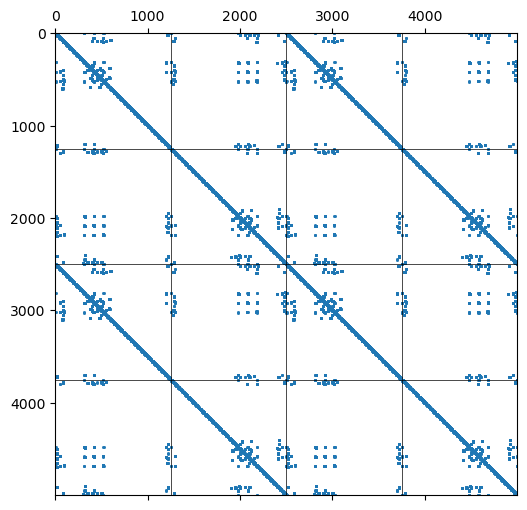

<Figure size 640x480 with 0 Axes>

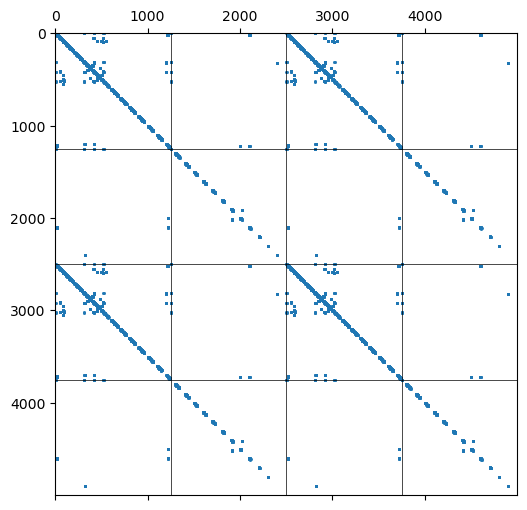

<Figure size 640x480 with 0 Axes>

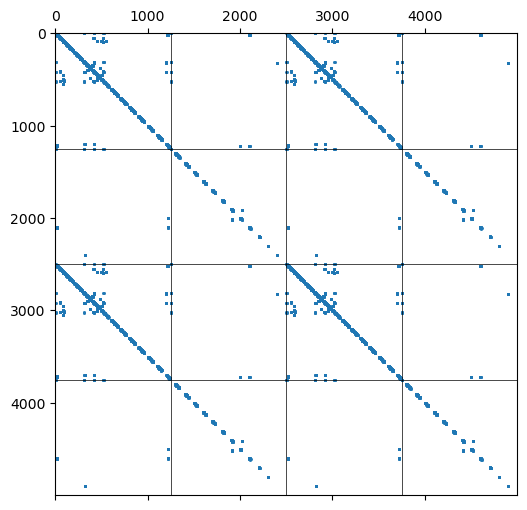

In [5]:
fig = plt.figure()
spy(cov_t)
fig = plt.figure()
spy(cov_r)
fig = plt.figure()
spy(cov_r2)

In [6]:
ism = InputStatisticsManager.from_name(
    "memory_effect_test_0.4", parent_data_dir="/mnt/raid/rmt/data/"
)
pm = ism.get_matrix_pool_manager()

[11/21 17:24:00] Loading statistics from memory...
[11/21 17:24:00] Done


In [7]:
chol = pm.chol

size_of_S = len(pm.mean_S)
size_of_t = int(size_of_S // 2)
num_random_numbers, _ = chol["t"].shape


random_numbers = np.random.randn(3, num_random_numbers, 10)
modified_random_numbers_t = chol["t"] @ random_numbers[0]
modified_random_numbers_r = chol["r"] @ random_numbers[1]
modified_random_numbers_r2 = chol["r2"] @ random_numbers[2]

# Pick out the correct values
reals_t = modified_random_numbers_t[: int(num_random_numbers / 2)]
imags_t = modified_random_numbers_t[int(num_random_numbers / 2) :]
reals_r = modified_random_numbers_r[: int(num_random_numbers / 2)]
imags_r = modified_random_numbers_r[int(num_random_numbers / 2) :]
reals_r2 = modified_random_numbers_r2[: int(num_random_numbers / 2)]
imags_r2 = modified_random_numbers_r2[int(num_random_numbers / 2) :]

r = reals_r + 1j * imags_r
t = reals_t + 1j * imags_t
r2 = reals_r2 + 1j * imags_r2

# Reorder the randomly generated numbers into the correct shapes
r_mat = pm._reorder_block(r).transpose(2, 0, 1)
t_mat = pm._reorder_block(t).transpose(2, 0, 1)
r2_mat = pm._reorder_block(r2).transpose(2, 0, 1)

sigma_p = matrix_utils.get_S_block_reciprocity_matrix(size_of_t, False)[None, :, :]

r_mat_antidiagonal = matrix_utils.get_sub_block_antidiagonal(r_mat)
r_mat = r_mat + sigma_p @ matrix_utils.r_sym(r_mat) @ sigma_p
r_mat_antidiagonal = (
    r_mat_antidiagonal
    + sigma_p @ matrix_utils.r_sym(r_mat_antidiagonal) @ sigma_p
) / 2

r2_mat_antidiagonal = matrix_utils.get_sub_block_antidiagonal(r2_mat)
r2_mat = r2_mat + sigma_p @ matrix_utils.r_sym(r2_mat) @ sigma_p
r2_mat_antidiagonal = (
    r2_mat_antidiagonal
    + sigma_p @ matrix_utils.r_sym(r2_mat_antidiagonal) @ sigma_p
) / 2


t2_mat = sigma_p @ matrix_utils.r_sym(t_mat) @ sigma_p
output = np.block([[r_mat, t2_mat], [t_mat, r2_mat]])

In [8]:
output.shape

(10, 100, 100)

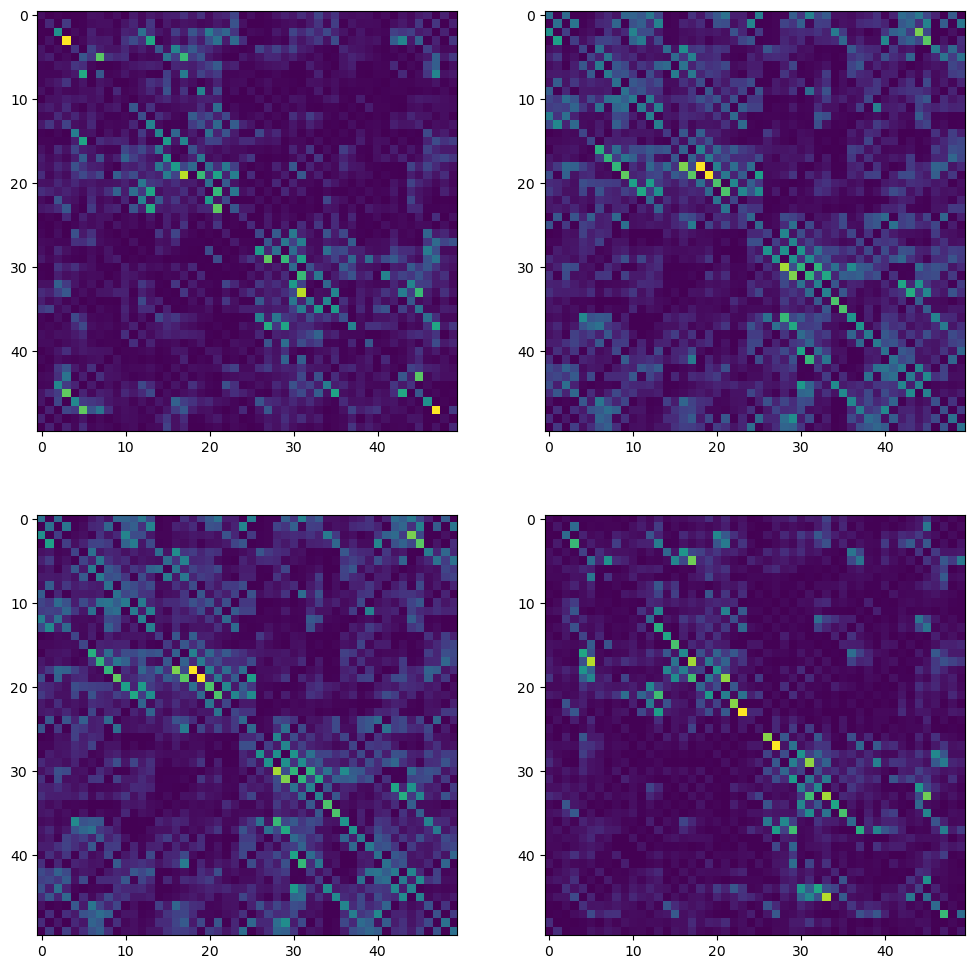

In [9]:
fig, axs = plt.subplots(2,2,figsize=(12,12))
axs[0,0].imshow(np.abs(r_mat[0]))
axs[1,0].imshow(np.abs(t_mat[0]))
axs[0,1].imshow(np.abs(t_mat[0]))
axs[1,1].imshow(np.abs(r2_mat[0]))

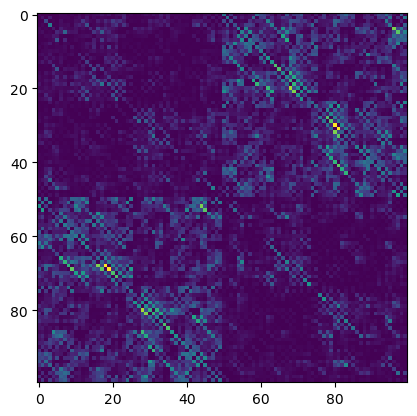

In [10]:
plt.imshow(np.abs(output[0]))

In [11]:
w = matrix_utils.get_S_reciprocity_matrix(len(output[0]))
for S in output:
    print(np.max( S - w.conj()@S.T@w))


0j
0j
0j
0j
0j
0j
0j
0j
0j
0j


In [12]:
for i in mode_grid.propagating_indices:
    print(matrix_utils.get_sub_block(S[0], "r", (i,-i), is_reciprocal=True))
    

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
test = matrix_utils.get_sub_block(S[0], "r", (3,-3), is_reciprocal=True)
print(test)
print("----------")
print(matrix_utils.get_sub_block(S[0], "t", (3,-3), is_reciprocal=True))
print(matrix_utils.get_sub_block(S[0], "t2", (3,-3), is_reciprocal=True))

[[ 2.43886270e-03-2.50621626e-03j -1.89664886e-08-9.38134266e-09j]
 [-2.22723789e-08-1.62878973e-08j -2.43877666e-03+2.50615944e-03j]]
----------
[[ 1.46288383e-03+1.08724593e-04j -8.00147362e-09+8.01887588e-08j]
 [-2.65267998e-08-2.22110813e-08j -1.36289298e-02-7.12163983e-03j]]
[[ 1.46288383e-03+1.08724593e-04j  2.65267998e-08+2.22110813e-08j]
 [ 8.00147362e-09-8.01887588e-08j -1.36289298e-02-7.12163983e-03j]]


In [ ]:
# ki = np.random.randn(3)
# ki = ki / np.linalg.norm(ki)
ki = np.array(mode_grid.by_index(0).center)
ki = np.array([ki[0], ki[1], np.sqrt(1 - ki[0]**2 - ki[1]**2)])

kib = np.array(mode_grid.by_index(0).center)
kib = np.array([kib[0], kib[1], -np.sqrt(1 - kib[0]**2 - kib[1]**2)])
print(ki)
print(kib)
mat = isotropic_sphere.get_A(
    np.array([ki[0]]),
    np.array([ki[1]]),
    np.array([ki[2]]),
    np.array([kib[0]]),
    np.array([kib[1]]),
    np.array([kib[2]]),
    np.array([2.0]),
    np.array([1.2])
)
print(mat.reshape(2,2))

print(get_T(ki, kib, {"x": 2.0, "m": 1.2, "type": "mie"}))

[0. 0. 1.]
[ 0.  0. -1.]
[[ 0.04854149+0.03255906j  0.        +0.j        ]
 [ 0.        +0.j         -0.04854149-0.03255906j]]
[[-4.85414803e-02-3.27136970e-02j -5.94461685e-18-4.00627243e-18j]
 [-5.94461685e-18-4.00627243e-18j  4.85414803e-02+3.27136970e-02j]]


/home/nbyrnes/code/random-matrix/random_matrix/amplitude_matrix/scattering_geometry.py:30: RuntimeWarning: invalid value encountered in divide
  e_phi /= mod_kappa[..., xp.newaxis]
/home/nbyrnes/code/random-matrix/random_matrix/amplitude_matrix/scattering_geometry.py:44: RuntimeWarning: invalid value encountered in divide
  e_theta /= xp.sqrt(


In [ ]:
# ki = np.random.randn(3)
# ki = ki / np.linalg.norm(ki)
ki = np.array(mode_grid.by_index(-7).center)
ki = np.array([ki[0], ki[1], np.sqrt(1 - ki[0]**2 - ki[1]**2)])

kib = np.array(mode_grid.by_index(-3).center)
kib = np.array([kib[0], kib[1], -np.sqrt(1 - kib[0]**2 - kib[1]**2)])
print(ki)
print(kib)
mat = isotropic_sphere.get_A(
    np.array([ki[0]]),
    np.array([ki[1]]),
    np.array([ki[2]]),
    np.array([kib[0]]),
    np.array([kib[1]]),
    np.array([kib[2]]),
    np.array([2.0]),
    np.array([1.2])
)
print(mat.reshape(2,2))

print(get_T(ki, kib, {"x": 2.0, "m": 1.2, "type": "mie"}))

[0.4        0.4        0.82462113]
[ 8.31918359e-01 -5.55111512e-18 -5.54898048e-01]
[[0.05145672-0.09047695j 0.02662748-0.08326992j]
 [0.06081743-0.15410683j 0.1016629 -0.22676595j]]
[[-0.05145672+0.09052842j -0.02662748+0.0832262j ]
 [-0.06081743+0.15407662j -0.1016629 +0.22677498j]]


In [ ]:
matrix = np.array([[1,2],[3,4]])

M, N = matrix.shape
b = np.ones((M, N), dtype=matrix.dtype)
b[1::2, ::2] = -1.0
b[::2, 1::2] = -1.0
print(matrix.T * b)
print(b)


[[ 1 -3]
 [-2  4]]
[[ 1 -1]
 [-1  1]]


In [ ]:
test2 = (sigma_p[None, :, :]@ matrix_utils.r_sym(r_mat)@ sigma_p[None, :, :])[0][48:50,0:2]
print(test2)

[[-2.89093554e-05+9.34542066e-04j  8.30834338e-10-2.31627080e-08j]
 [-3.38434199e-08-4.11173938e-08j  2.88943976e-05-9.34575813e-04j]]


In [ ]:
sigma_p = matrix_utils.get_S_block_reciprocity_matrix(
    size_of_t, use_cupy
)
t2_mat = (
    sigma_p[None, :, :]
    @ matrix_utils.r_sym(t_mat)
    @ sigma_p[None, :, :]
)
output = xp.block([[r_mat, t2_mat], [t_mat, r2_mat]])


In [ ]:
diff = cov - cov_v2
half_size = diff.shape[0]//2
diff

<3528x3528 sparse matrix of type '<class 'numpy.float64'>'
	with 0 stored elements in Compressed Sparse Row format>

In [ ]:
print(matrix_utils.get_cov_sub_block_from_indices(
    83,355,True,21))

('r,r', (10, -10, -6, -6))


In [ ]:
print(cov[83,355])
print(cov_v2[83,355])

0.0
0.0


In [ ]:
print(diff)

In [ ]:
print(matrix_utils.get_cov_sub_block_from_indices(416,1828-half_size,True,21))

('r,r', (10, -6, 6, -10))


In [ ]:
print(cov[416:420,1828:1832].todense())

[[ 0.00000000e+00 -2.22018833e-07 -2.22018833e-07 -9.99084747e-08]
 [-2.22018833e-07 -4.67179217e-22  0.00000000e+00 -2.22018833e-07]
 [-2.22018833e-07  0.00000000e+00  4.67179217e-22 -2.22018833e-07]
 [ 9.99084747e-08 -2.22018833e-07 -2.22018833e-07  0.00000000e+00]]


In [ ]:
print(cov_v2[416:420,1828:1832].todense())

[[ 0.00000000e+00 -2.22018833e-07 -2.22018833e-07 -9.99084747e-08]
 [-2.22018833e-07 -4.67179217e-22  0.00000000e+00 -2.22018833e-07]
 [-2.22018833e-07  0.00000000e+00  4.67179217e-22 -2.22018833e-07]
 [ 9.99084747e-08 -2.22018833e-07 -2.22018833e-07  0.00000000e+00]]


In [ ]:
cov_real_size, _ = cov_real.shape
cov_size, _ = cov.shape
print(cov_real_size)
print(cov_size)

NameError: name 'cov_real' is not defined

In [ ]:
print(np.max(np.abs(cov_real[:1764,:1764] - 0.5*cov.real)))
print(np.max(np.abs(cov_real[1764:,1764:] - 0.5*cov.real)))

print(np.max(np.abs(cov_real[:1764,1764:] + 0.5*cov.imag)))
print(np.max(np.abs(cov_real[1764:,:1764] - 0.5*cov.imag)))


0.0
0.0
0.0
0.0


In [ ]:
cov_real_computed = 0.5*np.block([[cov.real, -cov.imag],[cov.imag, cov.real]])

In [ ]:
print(np.max(np.abs(cov_real - cov_real_computed)))
idx = np.unravel_index(
    np.argmax(np.abs(cov_real - cov_real_computed)),
    cov_real.shape
)

print(idx)

0.0
(0, 0)


In [ ]:
print(cov_size)
print(707+1059)

1764
1766


In [ ]:
print(cov_real[idx])
print(cov_real_computed[idx])

0.0008440278445400877
0.0008440278445400877


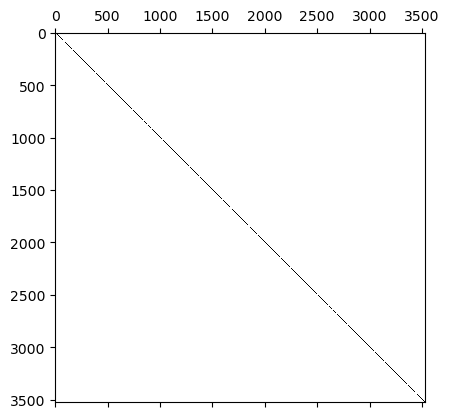

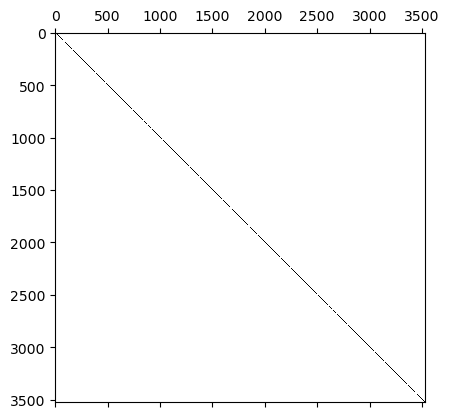

In [ ]:
plt.figure()
plt.spy(cov_real)
plt.figure()
plt.spy(cov_real_computed)

In [ ]:
idx = np.unravel_index(
    np.argmax(np.abs(cov_real - cov_real_computed)),
    cov_real.shape
)

print(idx)


(0, 0)


In [ ]:
print(cov_real[400,2167])
print(cov_real_computed[400,2167])

-7.763994776113712e-06
-7.763994776113712e-06


In [ ]:
mat = np.random.randn(100, 100) + 1j * np.random.randn(100, 100)
A_d = mat @ np.conj(mat).T
A_s = scipy.sparse.csc_matrix(A_d)

In [ ]:
# Direct cholesky decomps
C_d = np.linalg.cholesky(A_d)
C_s = sksparse.cholmod.cholesky(A_s).L()

diff = C_d - C_s
print(C_d - C_s)
print(np.max(diff))

[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]
0j


In [ ]:
C_d = matrix_utils.block_cholesky(A_d)
C_s = matrix_utils.block_cholesky_sparse(A_s)

diff = C_d - C_s.todense()
print(diff)
print(np.max(np.abs(diff)))

[[ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j ...  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j ...  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00-1.11022302e-16j  1.38777878e-17-2.22044605e-16j
   0.00000000e+00+0.00000000e+00j ...  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 ...
 [ 0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j ... -2.57571742e-14+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  0.00000000e+00+0.00000000e+00j]
 [ 2.22044605e-16+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j ...  9.15101328e-14-4.44783099e-14j
  -4.35207426e-14+0.00000000e+00j  0.00000000e+

/home/nbyrnes/code/random-matrix/random_matrix/utils/matrix_utils.py:620: CholmodTypeConversionWarning: converting matrix of class csr_matrix to CSC format
  X = A11_factor.solve_L(A21.conj().T, use_LDLt_decomposition=False).conj().T


In [ ]:
np.max(C_d @ np.conj(C_d.T) - A_d)

(5.684341886080802e-14+0j)

In [ ]:
# Block numpy
C_d_block = matrix_utils.block_cholesky(A_d)

diff = C_d - C_d_block
print(C_d - C_d_block)
print(np.max(np.abs(diff)))

[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]
0.0


In [ ]:
C_s_1 = sksparse.cholmod.cholesky(A_s).L().toarray()
C_s_2 = sksparse.cholmod.cholesky(A_s, ordering_method="natural").L().toarray()
diff = C_s_1 - C_s_2
print(diff)
print(np.max(np.abs(diff)))

[[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 ...
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]]
0.0


0j


/tmp/ipykernel_496773/1721640579.py:12: CholmodTypeConversionWarning: converting matrix of class csr_matrix to CSC format
  X = A11_factor.solve_L(A21.conj().T, use_LDLt_decomposition=False).conj().T


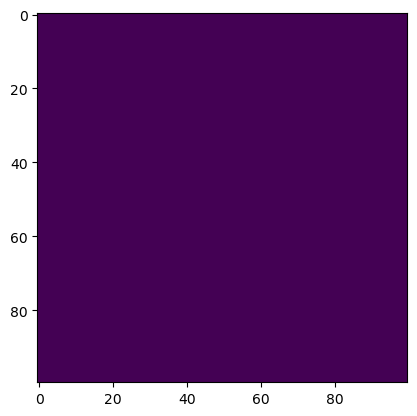

In [ ]:
n = A_s.shape[0]
k = n // 2

# Split blocks
A11 = A_s[:k, :k]
A21 = A_s[k:, :k]
A22 = A_s[k:, k:]

# Sparse calculations
A11_factor = sksparse.cholmod.cholesky(A11)
L11 = A11_factor.L()
X = A11_factor.solve_L(A21.conj().T, use_LDLt_decomposition=False).conj().T
S = A22 - X @ X.conj().T
Ls = sksparse.cholmod.cholesky(S).L()

L_top = scipy.sparse.hstack(
    [L11, scipy.sparse.csr_matrix((k, k))], format="csr"
)
L_bottom = scipy.sparse.hstack([X, Ls], format="csr")
L = scipy.sparse.vstack([L_top, L_bottom], format="csr")


diff = L - C_s
plt.imshow(np.abs(diff.todense()))
print(np.max(diff))

In [ ]:
print(np.max(L11 @ X - A21.conj().T))

(75.30471513904172+5.985200938397078j)


In [ ]:
print(np.min(np.linalg.eigvals(L11.todense())))
# L11_factor = sksparse.cholmod.cholesky(L11).L()
np.max(L11 - L11.T)

(8.852509003266947+0j)


(3.576499974601-1.3761622790195813j)

In [ ]:
L11_container = sksparse.cholmod.cholesky(A11)
L11 = L11_container.L()
L21 = L11_container.solve_A(A21.T.conj()).T.conj()
S = A22 - L21 @ L21.conj().T

L22 = sksparse.cholmod.cholesky(S).L()

# Step 5: Combine blocks
L_top = scipy.sparse.hstack(
    [L11, scipy.sparse.csc_matrix((k, n - k), dtype=A.dtype)]
)
L_bottom = scipy.sparse.hstack([L21, L22])
L = scipy.sparse.vstack([L_top, L_bottom])

/tmp/ipykernel_496773/585127219.py:3: CholmodTypeConversionWarning: converting matrix of class csr_matrix to CSC format
  L21 = L11_container.solve_A(A21.T.conj()).T.conj()


NameError: name 'A' is not defined